# EEG-ECMR

Jordan Gunn  
November 13, 2025

This document records our progress and key decisions as we build a brain-based version of eCMR using EEG data from Zarubin et al. (2020).

Prior analyses of the dataset provide two anchors. First, emotionally negative items are recalled more often than neutral items. Second, early LPP amplitudes during study predict subsequent recall of emotional items but not neutral items. These findings confirm that LPPs index neural processes relevant to emotional memory enhancement. However, they do not in themselves explain how neural

describe patterns but do not explain how neural signals could mechanistically drive recall.

To close this gap, we specify computational cognitive models that implement alternative linking hypotheses about how LPP signals interact with attention and context-binding processes at encoding. We simulate trials and score each model by the likelihood of the observed recalled sets. This quantifies how well proposed neurocognitive mechanisms can explain the full pattern of recalled items on each trial.

Our evaluation adapts LPP inputs within the retrieved-context framework, where learned item–context associations drive recall dynamics. In this framework, emotional items bind to emotion-specific context features and attract more attention, increasing their odds of winning recall competition. We compare accounts of how LPPs modulate these processes. By forcing LPP signals to operate through the model’s internal dynamics and then evaluating the full recalled set, we ask not merely whether LPPs correlate with recall but whether they drive recall through specific cognitive mechanisms.

## Data Preparation

The primary analysis table is `Single_Trial_Behavioural_and_EEG_Data_Z.csv` (`Z:\Talmi lab space\Archive\Secondary_Data_Analysis_Zarubin_From_Robin\Manuscript\files from robin nov24\`). That table is identical across available copies in the lab server but omits study events lacking reliable EEG measures. To restore those events, we merged it with the behavioral log `All_Included_Subjects.csv` (`Z:\Talmi lab space\Archive\Secondary_Data_Analysis_Zarubin_From_Robin\Data\Behaviour\Behaviour_csv_files\`), which contains recall status for every non‑buffer item but no LPP scores. Prior to merging, we verified that recalled/not‑recalled labels are consistent across sources (e.g., no item marked “recalled” in the EEG file is marked “not recalled” in the behavioral log).

The merged dataset contains 6,840 study events from 342 list trials, with 20 analyzable items per list after trimming the two buffer positions. Of these events, 371 (5.42%) lack EEG measurements. Missingness is similar across valence conditions: negative lists contribute 125 of 2,266 events (5.52%; mean 0.37 ± 0.65 items missing per trial) and neutral lists contribute 246 of 4,574 events (5.38%; mean 0.72 ± 0.93 items missing per trial). Overall, 202 of 342 lists (59.1%) include at least one missing LPP value; among affected lists, 1.84 ± 1.01 items are missing (median 2; maximum 6). Across participants, missing exposure ranges from 2 to 19 items (3.9–10% of each person’s 180 study events), making imputation methodologically substantive.

LPP amplitudes are imputed hierarchically. For any study event still missing an LPP value after merging, the fill value is the participant’s mean for items of the same emotion within the same trial. This preserves within‑person, within‑trial, and emotion‑specific structure and avoids borrowing information across trials or valence conditions.

Each original list contained 22 items, but the first two positions were designated as primacy buffers to prevent primacy from confounding emotion–memory effects. Those buffer items were excluded upstream, and their recall status is not recorded in the available materials. Because the buffers cannot be recovered, lists are analyzed as 20‑item sequences.

The dataset records whether each item was recalled but not recall order. Consequently, model fitting uses loss functions defined over the recalled set per trial rather than over output sequences. This is accomodated in our likelihood-based evaluation by focusing on the probability assigned to the observed recalled set rather than the sequence in which items were recalled.

## Benchmark Analyses

These checks do two things. They verify that data preparation worked. They also set clear targets for model development. Unless noted, error bars show 95% bootstrapped confidence intervals across participants. We may switch to hierarchical (subject and trial level) confidence intervals later to better account for data structure.

### Emotional Enhancement of Memory

Our main behavioral check is the category serial position curve. It appears in the “Meeting with Nathaniel Daw” slides on the lab drive. For each position, we compute the share of items recalled among items with that category label. The close match between the shared and regenerated curves builds confidence that data preparation worked as intended.

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr class="odd">
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p>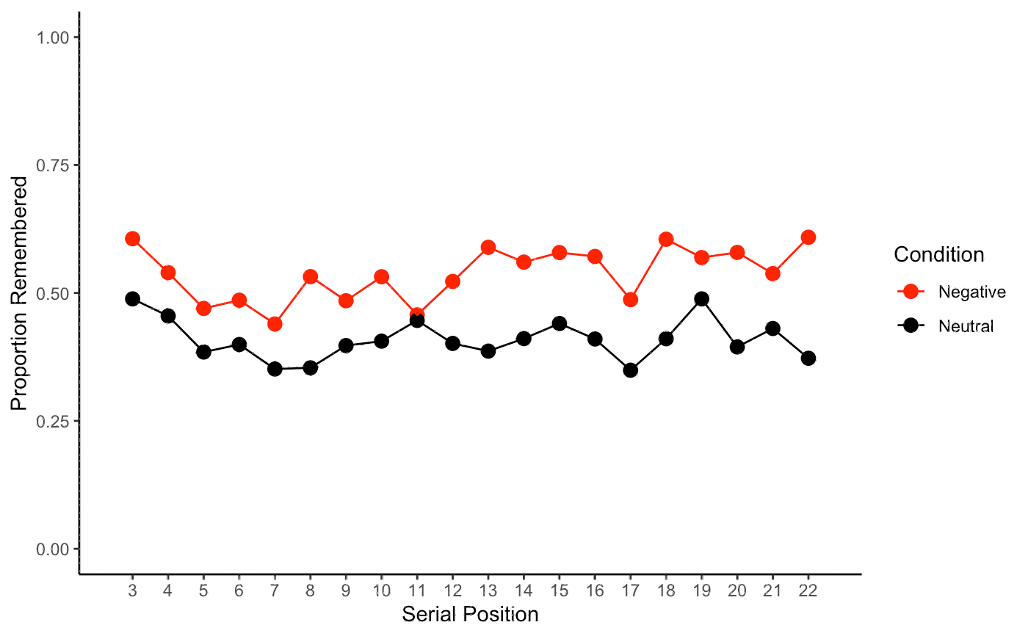</p>
</div></td>
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p>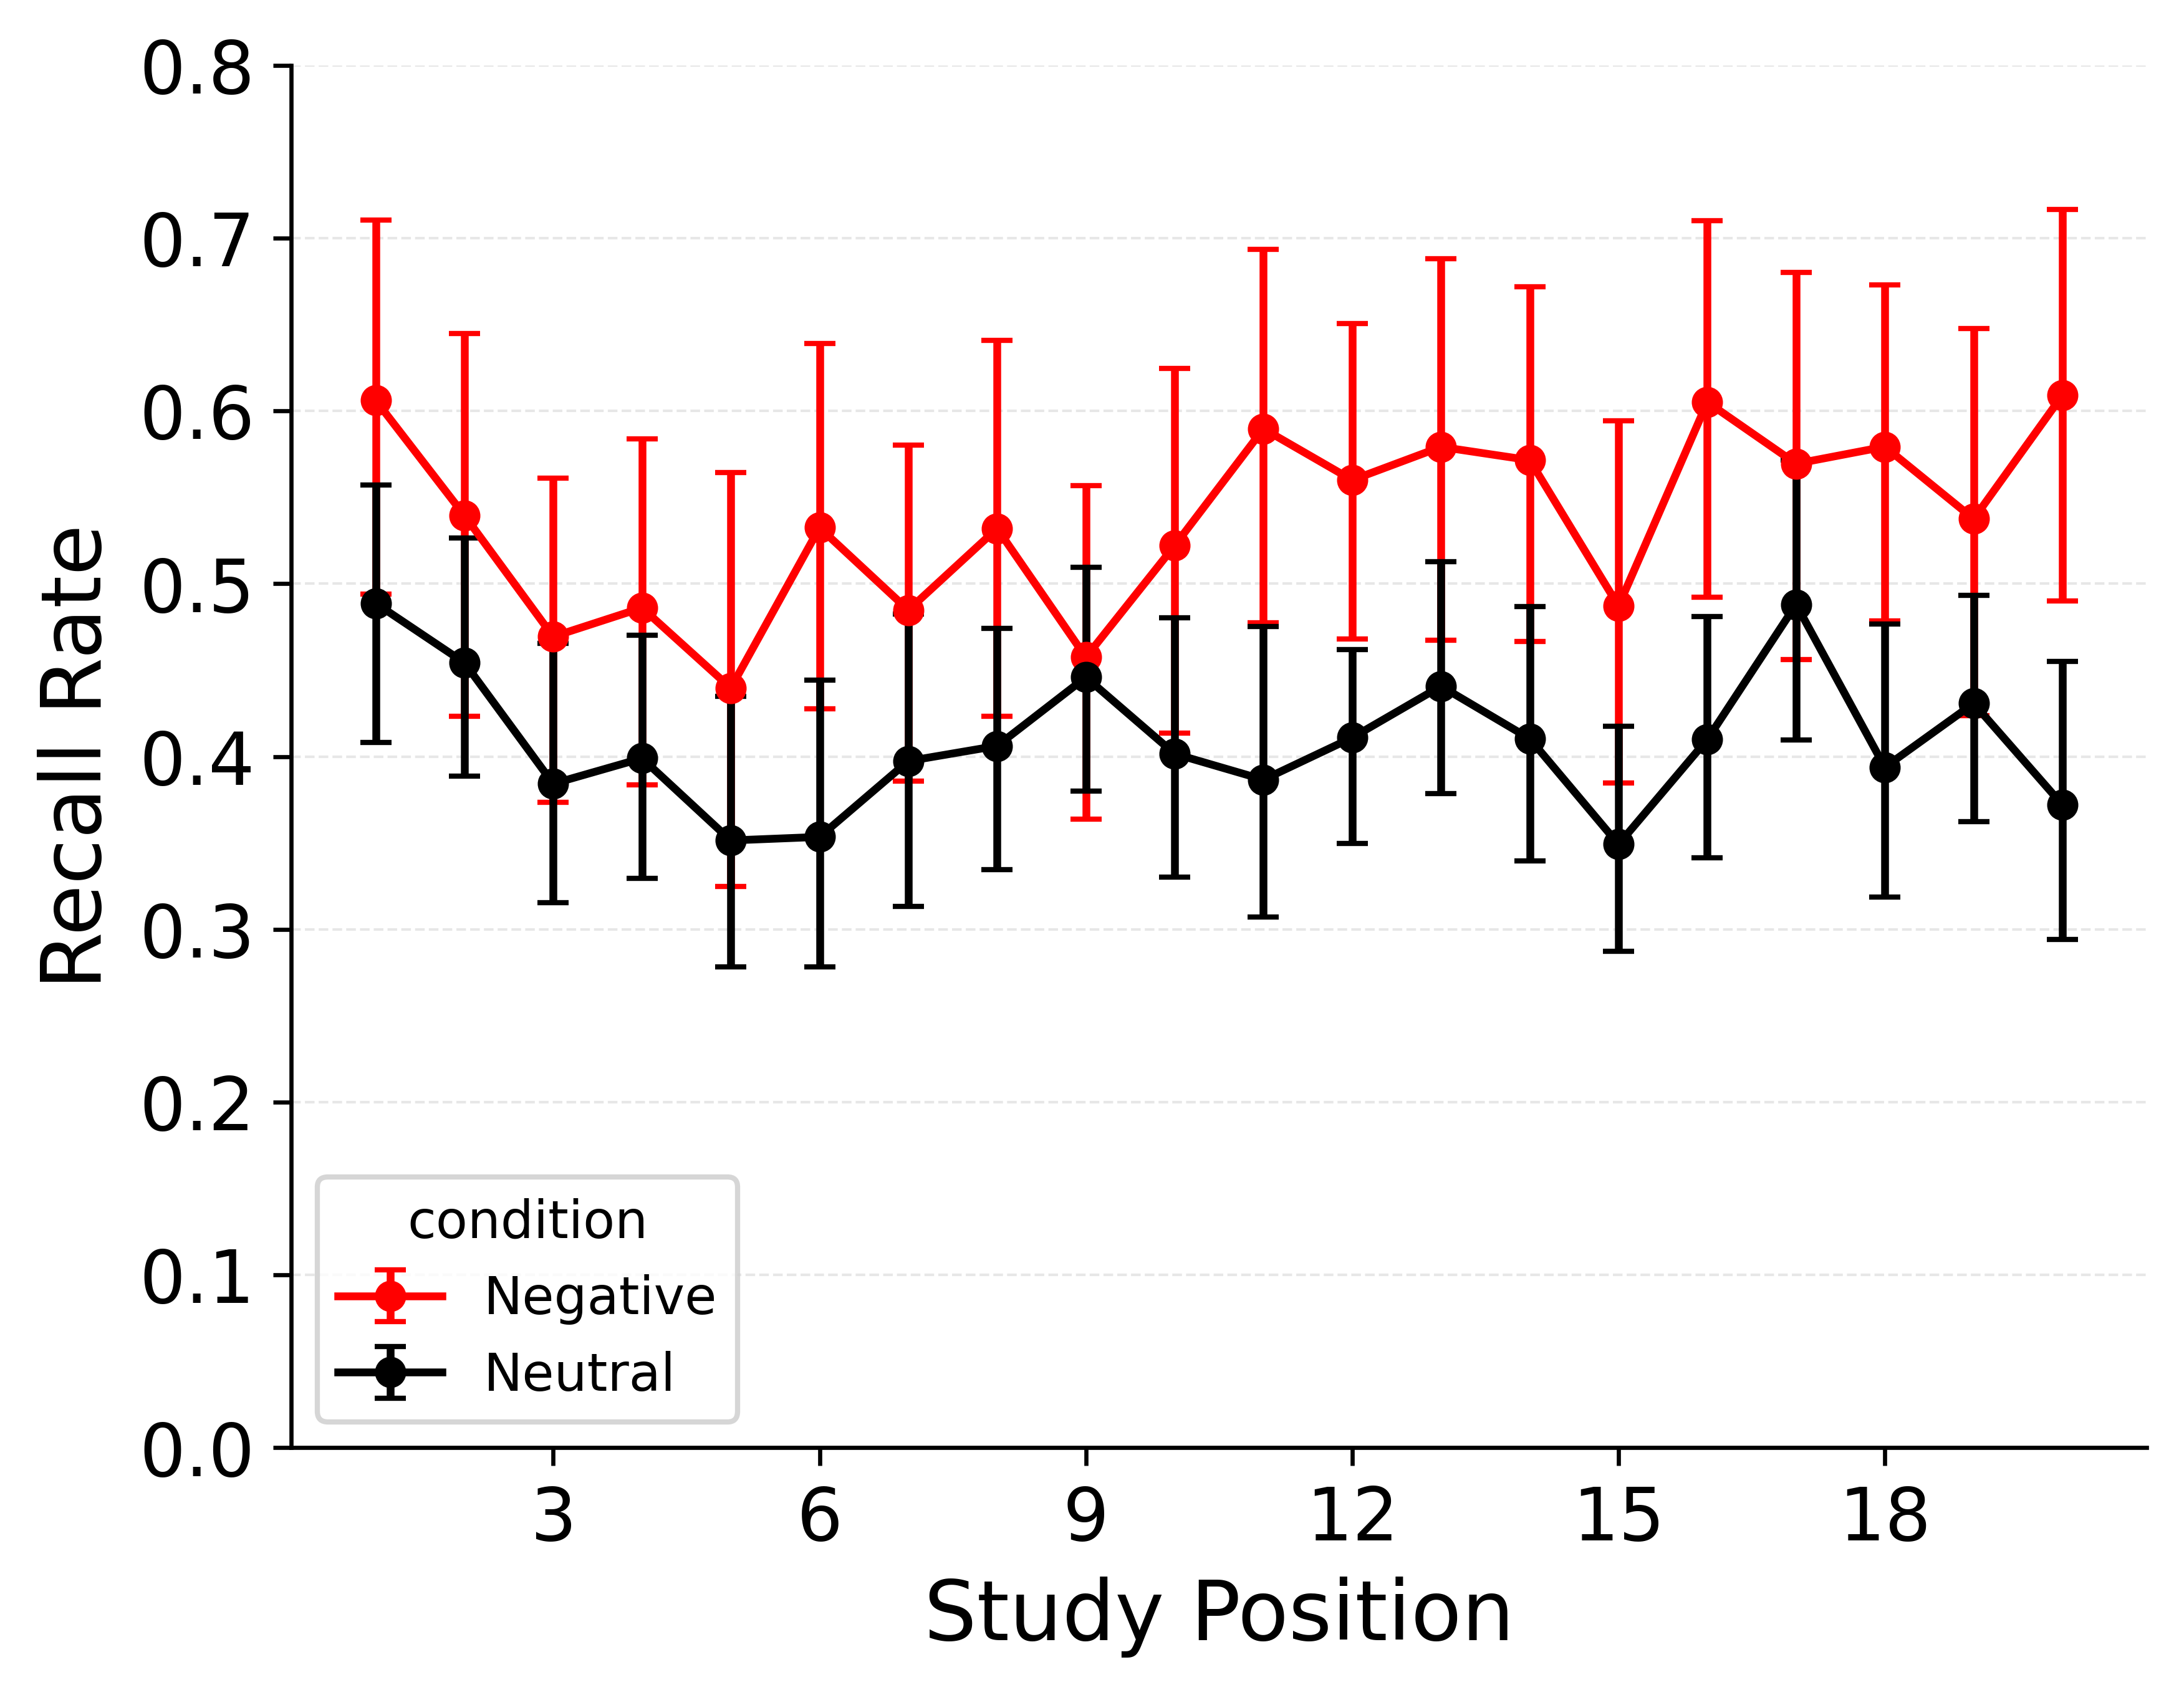</p>
</div></td>
</tr>
</tbody>
</table>

Recall rate by study position and item type from reference materials (LEFT) and from the present dataset (RIGHT).